# Linear Regression Tutorial - Following Chapter 4 Approach

This notebook walks through my attempt to fit a Bayesian linear regression model to the data Edmund shared (number of promotions and expected book value in a feature deals email), following the approach from Statistical Rethinking Chapter 4.

## Setup

First, I imported the required libraries. I'm more or lesss following the same setup as the practice problems.

In [2]:
import pandas as pd
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
import jax.numpy as jnp
from jax import random

import numpyro  
import numpyro.distributions as dist
import numpyro.optim as optim
from numpyro.infer import SVI, Trace_ELBO, Predictive
from numpyro.infer.autoguide import AutoLaplaceApproximation
from numpyro.infer import init_to_value

az.style.use("arviz-darkgrid")
numpyro.set_platform("cpu")

/Users/annecarlson/bookbub/statistical-rethinking-practice/.venv/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


## Load and Explore the Data

I wanted to start by better understanding the data. It has:
- **N_PROMOS**: Number of promotions shown to a user (predictor)
- **EXPECTED_BOOK_VALUE**: Expected value in cents (outcome we want to predict)

The full dataset has ovwr 16M rows. I'm using 100k rows so it's faster to work with.


In [3]:
df = pd.read_csv('linear-regression-set.csv')

# Check how many nonzero values we have
non_zero_count = (df['EXPECTED_BOOK_VALUE'] > 0).sum()
print(f"\nnonzero values: {non_zero_count} ({100*non_zero_count/len(df):.1f}%)")

print("\nsample first few rows:")
df.head()


nonzero values: 3078108 (18.2%)

first few rows:


,USER_ID,MAILING_ID,N_PROMOS,EXPECTED_BOOK_VALUE
0,8791556,118787,9,0.0
1,11782848,119278,29,0.0
2,34546691,119147,8,0.0
3,34116673,118404,15,0.0
4,9599092,120293,7,0.0


### Visualizing the Data

Then I looked at the distrbiutions and relationship between variables. This isn't in the book, I just wanted to better understand what the data was like.

/private/tmp/nix-shell-22145-1050903934/ipykernel_48312/3997429207.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()
/private/tmp/nix-shell-22145-1050903934/ipykernel_48312/3997429207.py:25: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


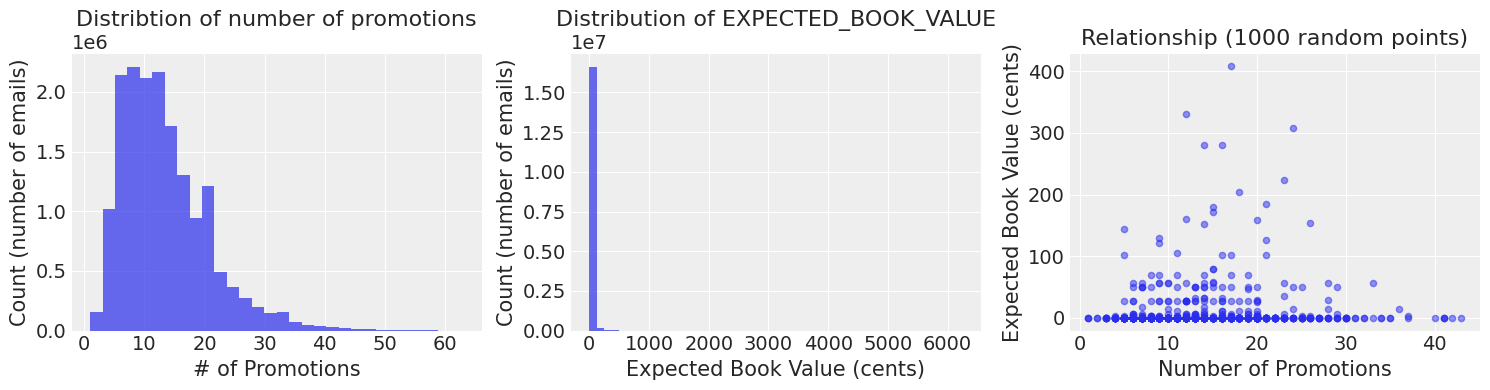

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution of N_PROMOS
axes[0].hist(df['N_PROMOS'], bins=30, alpha=0.7)
axes[0].set_xlabel('# of Promotions')
axes[0].set_ylabel('Count (number of emails)')
axes[0].set_title('Distribtion of number of promotions')
axes[0].legend()

# Distribution of EXPECTED_BOOK_VALUE
axes[1].hist(df['EXPECTED_BOOK_VALUE'], bins=50, alpha=0.7)
axes[1].set_xlabel('Expected Book Value (cents)')
axes[1].set_ylabel('Count (number of emails)')
axes[1].set_title('Distribution of EXPECTED_BOOK_VALUE')

# Scatter plot (sample for visibility)
sample_idx = np.random.choice(len(df), min(1000, len(df)), replace=False)
axes[2].scatter(df.iloc[sample_idx]['N_PROMOS'],
                df.iloc[sample_idx]['EXPECTED_BOOK_VALUE'],
                alpha=0.5, s=20)
axes[2].set_xlabel('Number of Promotions')
axes[2].set_ylabel('Expected Book Value (cents)')
axes[2].set_title('Relationship (1000 random points)')

plt.tight_layout()
plt.show()

This taught me a little about the data, most notable that most expected book values are 0. I also noticed that non zero values seem to cluster around certian values (presumably related to categories about the book). This is very different from the continuous height data in the tutorial.

## Prepare Data for Modeling

I centered the weights by subtracting the mean. This is to make the intercetp the expected value at the average number of promotions:

In [8]:
X = jnp.array(df['N_PROMOS'].values)
y = jnp.array(df['EXPECTED_BOOK_VALUE'].values)

# center the predictor (following Code 4.42from the book)
xbar = X.mean()  # mean number of promotions

# center X by subtracting the mean 
X_centered = X - xbar

print(f"\nOriginal mean of X (N_PROMOS): {xbar:.2f}")
#should be zero
print(f"Mean of centered X: {X_centered.mean():.4f}")
print(f"\ny (EXPECTED_BOOK_VALUE) mean : {y.mean():.2f}, std={y.std():.2f}")


Original X (N_PROMOS): mean=13.52
Centered X: mean=-0.0000

y (EXPECTED_BOOK_VALUE): mean=8.44, std=34.36


##\Define the Linear Model

Following the book's approach (Code 4.42), I defined a Bayesian linear regression model. 

In [5]:
def linear_model(X_centered, y):
    """
    Linear regression model following Chapter 4 approach.
    Similar to Code 4.42 in the book.
    """
    # Since X is centered, alpha represents the expected value when N_PROMOS = mean(N_PROMOS), 
    #similar to how the book uses Normal(178, 20) for height
    alpha = numpyro.sample('alpha', dist.Normal(y.mean(), y.std()))
    
    # prior for slope (beta). I wasn't really certain what to put here, 
    # so I put aa weakly informative prior like the book's Normal(0, 10)
    beta = numpyro.sample('beta', dist.Normal(0, 1))
    
    # prior for residual std dev (sigma) also I just started with a weakly informative prior
    sigma = numpyro.sample('sigma', dist.Uniform(0, 10))
    
    # linear predictor
    mu = numpyro.deterministic("mu", alpha + beta * X_centered)
    
    # likelihood:connecting to observed data
    numpyro.sample('y', dist.Normal(mu, sigma), obs=y)


### Visualizing Prior Predictions

Following Code 4.38-4.39 to see what regression lines our priors imply by sampling from them. These lines show what relationships our priors allow before seeing any data. If these look unreasonable, I should revise the priors, but I have such a poor idea of what would be reasonable here I'm not certain how to interpret them.

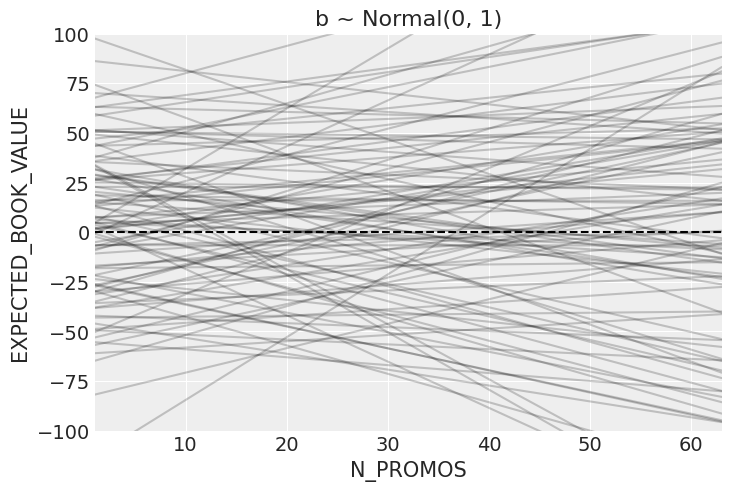

In [9]:
# Following Code 4.38-4.39 from the book
# sample from the priors to see what regression lines they imply

with numpyro.handlers.seed(rng_seed=2971):
    N = 100  # 100 lines
    # sample n values from each prior
    a = numpyro.sample("a", dist.Normal(y.mean(), y.std()).expand([N]))
    b = numpyro.sample("b", dist.Normal(0, 1).expand([N]))

plt.subplot(
  xlim=(X.min(), X.max()),
  ylim=(-100, 100),
  xlabel="N_PROMOS",
  ylabel="EXPECTED_BOOK_VALUE",
)
plt.axhline(y=0, c="k", ls="--")
plt.title("b ~ Normal(0, 1)")
xbar = X.mean()
x = jnp.linspace(X.min(), X.max(), 101)
for i in range(N):
  plt.plot(x, a[i] + b[i] * (x - xbar), "k", alpha=0.2)
plt.show()

## Fit the Model 

Use quadratic approximation (laplace) which:
1. Finds the mode of the posterior
2. Approximates the posterior as a gaussian distribution around that peak

In [22]:
m_linear = AutoLaplaceApproximation(linear_model)
svi = SVI(
  linear_model,
  m_linear,
  optim.Adam(1), #the optimaization method the model should use
  Trace_ELBO(), #The loss function for the model
  X_centered=X_centered,
  y=y,
)
svi_result = svi.run(random.PRNGKey(0), 2000)
params = svi_result.params

100%|██████████████████████████████████████████| 2000/2000 [01:02<00:00, 32.11it/s, init loss: 194466128.0000, avg. loss [1901-2000]: 153369664.0000]


##  visualize the regression

Now iw ant to visualize what the model learned:

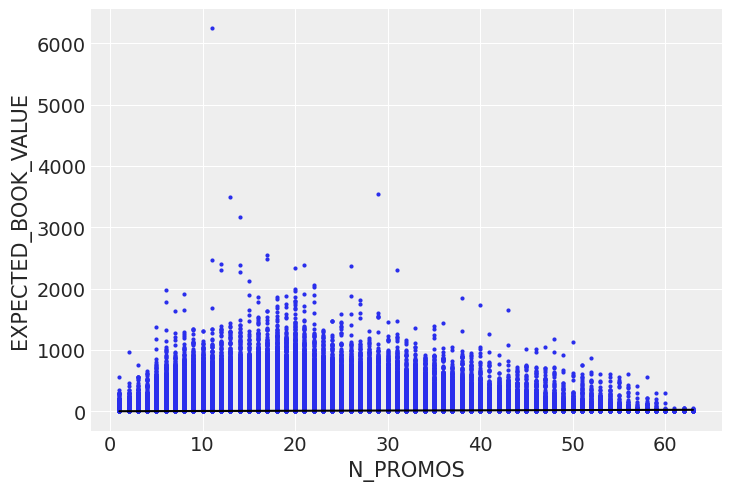

I did this


In [25]:
# following code 4.46  plot the data and the mean regression line
az.plot_pair(df[["N_PROMOS", "EXPECTED_BOOK_VALUE"]].to_dict(orient="list"))
post = m_linear.sample_posterior(random.PRNGKey(1), params, sample_shape=(1000,))
a_map = jnp.mean(post["alpha"])  # mean intercept
b_map = jnp.mean(post["beta"])   # mean slope
x = jnp.linspace(df.N_PROMOS.min(), df.N_PROMOS.max(), 101)
plt.plot(x, a_map + b_map * (x - xbar), "k")  # regression line using centered predictor
plt.show()


## Try Z-Score Normalization

The data has very high variance relative to the mean. Edmund suggested z-score normalization (not in the book) which transforms data to have mean=0 and std=1:

In [ ]:
# z-score normalization (standardization)
# Transform to mean=0, std=1
X_mean = X.mean()
X_std = X.std()
y_mean = y.mean()
y_std = y.std()

X_standardized = (X - X_mean) / X_std
y_standardized = (y - y_mean) / y_std
print(f"X_standardized: mean={X_standardized.mean():.4f}, std={X_standardized.std():.4f}")
print(f"y_standardized: mean={y_standardized.mean():.4f}, std={y_standardized.std():.4f}")

In [73]:
# Fit the same model but with standardized data
# The priors will automatically adjust since alpha uses y.mean() and y.std()
m_standardized = AutoLaplaceApproximation(linear_model)
svi_std = SVI(
    linear_model,
    m_standardized,
    optim.Adam(1),
    Trace_ELBO(),
    X_centered=X_standardized,  # Using standardized X (already centered at 0)
    y=y_standardized,            # Using standardized y
)
svi_result_std = svi_std.run(random.PRNGKey(0), 2000)
params_std = svi_result_std.params

print("Fitted model with standardized data!")

100%|██████████████████████████████████████████████| 2000/2000 [00:00<00:00, 2078.54it/s, init loss: 310005.0312, avg. loss [1901-2000]: 141686.4062]


Fitted model with standardized data!


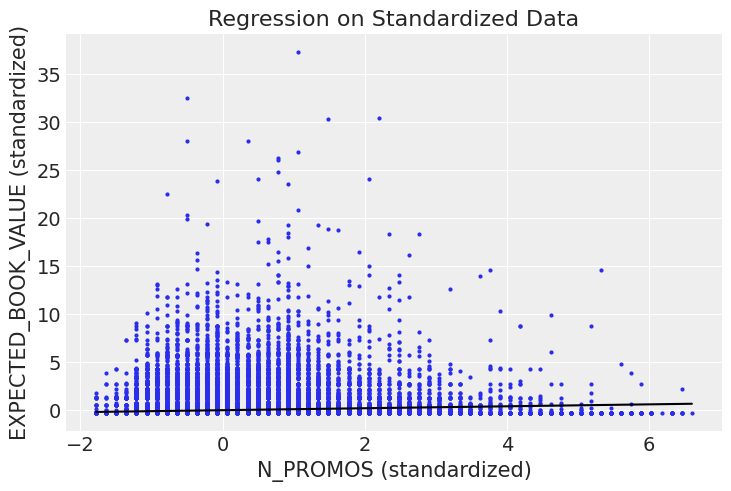

Standardized scale coefficients:
  alpha (intercept): -0.000
  beta (slope): 0.101


In [74]:
# Visualize the standardized model (Code 4.46 pattern)
az.plot_pair({"X_std": X_standardized, "y_std": y_standardized})
post_std = m_standardized.sample_posterior(random.PRNGKey(1), params_std, sample_shape=(1000,))
a_map_std = jnp.mean(post_std["alpha"])
b_map_std = jnp.mean(post_std["beta"])
x_std_range = jnp.linspace(X_standardized.min(), X_standardized.max(), 101)
plt.plot(x_std_range, a_map_std + b_map_std * x_std_range, "k")
plt.xlabel('N_PROMOS (standardized)')
plt.ylabel('EXPECTED_BOOK_VALUE (standardized)')
plt.title('Regression on Standardized Data')
plt.show()

print(f"Standardized scale coefficients:")
print(f"  alpha (intercept): {a_map_std:.3f}")
print(f"  beta (slope): {b_map_std:.3f}")

##  Fit on Non-Zero Values Only

Since 82% of the data is zeros, Edmund also suggested filtering to just the users who clicked (non zero book values) to see the relationship there:

In [28]:
# Filter to non-zero values only
df_nonzero = df[df['EXPECTED_BOOK_VALUE'] > 0].copy()
print(f"Non-zero data: {len(df_nonzero)} rows (was {len(df)} with zeros)")
print(f"\nSummary of non-zero data:")
print(df_nonzero[['N_PROMOS', 'EXPECTED_BOOK_VALUE']].describe())

# Prepare non-zero data
X_nz = jnp.array(df_nonzero['N_PROMOS'].values)
y_nz = jnp.array(df_nonzero['EXPECTED_BOOK_VALUE'].values)

# Center the predictor
xbar_nz = X_nz.mean()
X_nz_centered = X_nz - xbar_nz

print(f"\nNon-zero data characteristics:")
print(f"X (N_PROMOS): mean={xbar_nz:.2f}")
print(f"y (EXPECTED_BOOK_VALUE): mean={y_nz.mean():.2f}, std={y_nz.std():.2f}")

Non-zero data: 3078108 rows (was 16868933 with zeros)

Summary of non-zero data:
           N_PROMOS  EXPECTED_BOOK_VALUE
count  3.078108e+06         3.078108e+06
mean   1.472710e+01         4.626498e+01
std    6.941785e+00         6.870852e+01
min    1.000000e+00         3.600000e+00
25%    1.000000e+01         7.200000e+00
50%    1.400000e+01         2.800000e+01
75%    1.900000e+01         5.600000e+01
max    6.300000e+01         6.244600e+03

Non-zero data characteristics:
X (N_PROMOS): mean=14.73
y (EXPECTED_BOOK_VALUE): mean=46.26, std=68.71


In [29]:
# Fit model on non-zero data only
m_nonzero = AutoLaplaceApproximation(linear_model)
svi_nz = SVI(
    linear_model,
    m_nonzero,
    optim.Adam(1),
    Trace_ELBO(),
    X_centered=X_nz_centered,
    y=y_nz,
)
svi_result_nz = svi_nz.run(random.PRNGKey(0), 2000)
params_nz = svi_result_nz.params

print("Fitted model on non-zero data only")

100%|██████████████████████████████████████████| 2000/2000 [00:12<00:00, 154.49it/s, init loss: 147541920.0000, avg. loss [1901-2000]: 81961088.0000]


Fitted model on non-zero data only


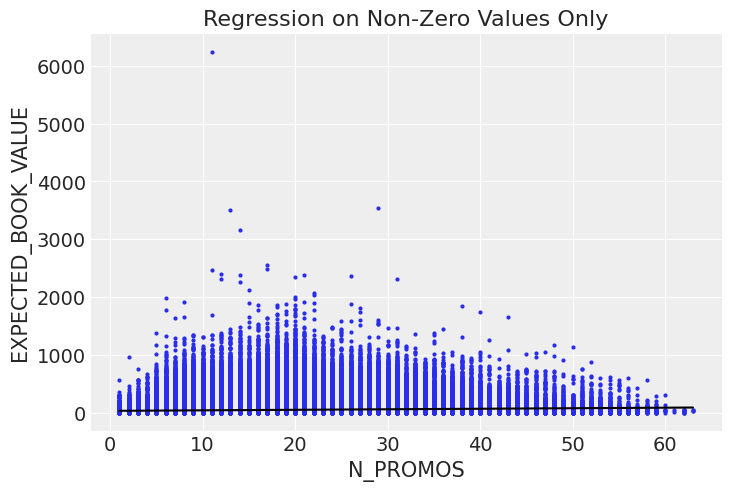

Non-zero model coefficients:
  Expected value at mean N_PROMOS (14.7): 46.26 cents
  Slope: 0.908 cents per promotion

Compare to original model (all data):
  Expected value at mean N_PROMOS (13.5): 8.44 cents
  Slope: 0.367 cents per promotion


In [30]:
# Visualize nonzero model
az.plot_pair(df_nonzero[["N_PROMOS", "EXPECTED_BOOK_VALUE"]].to_dict(orient="list"))
post_nz = m_nonzero.sample_posterior(random.PRNGKey(1), params_nz, sample_shape=(1000,))
a_map_nz = jnp.mean(post_nz["alpha"])
b_map_nz = jnp.mean(post_nz["beta"])
x_nz_range = jnp.linspace(df_nonzero.N_PROMOS.min(), df_nonzero.N_PROMOS.max(), 101)
plt.plot(x_nz_range, a_map_nz + b_map_nz * (x_nz_range - xbar_nz), "k")
plt.title('Regression on on non zero values only')
plt.show()

print(f"Non zero model coefficients:")
print(f"  Expected value at mean N_PROMOS ({xbar_nz:.1f}): {a_map_nz:.2f} cents")
print(f"  Slope: {b_map_nz:.3f} cents per promotion")

print(f"\ncompare to original model (all data):")
print(f"  Expected value at mean N_PROMOS ({xbar:.1f}): {a_map:.2f} cents")
print(f"  Slope: {b_map:.3f} cents per promotion")